<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

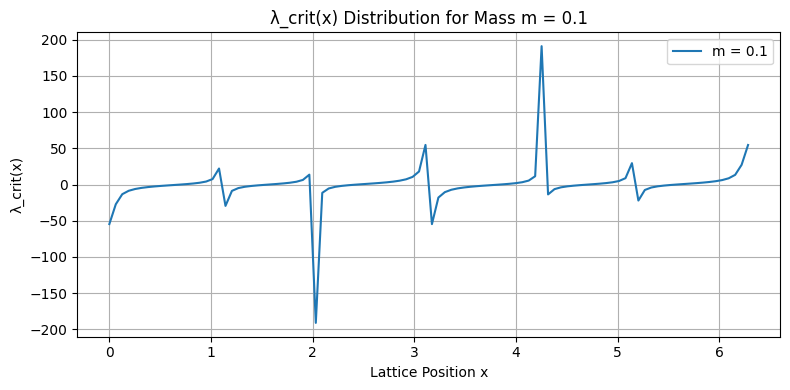

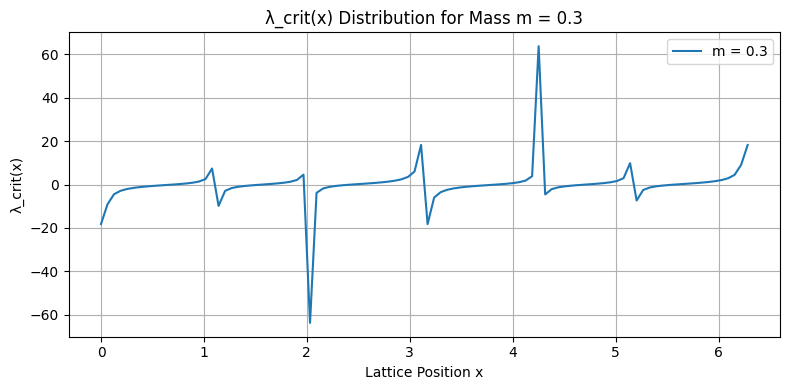

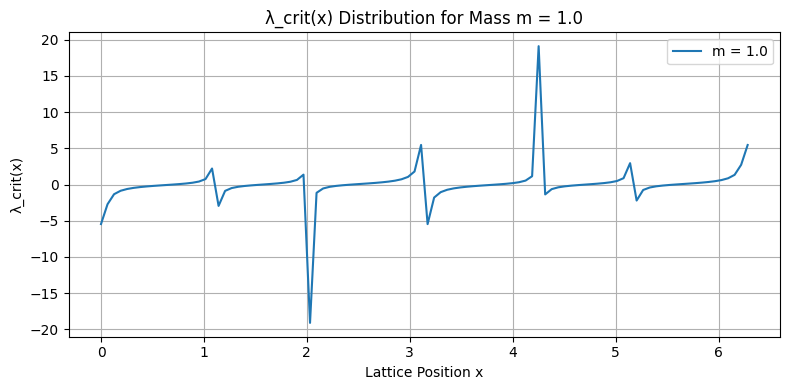

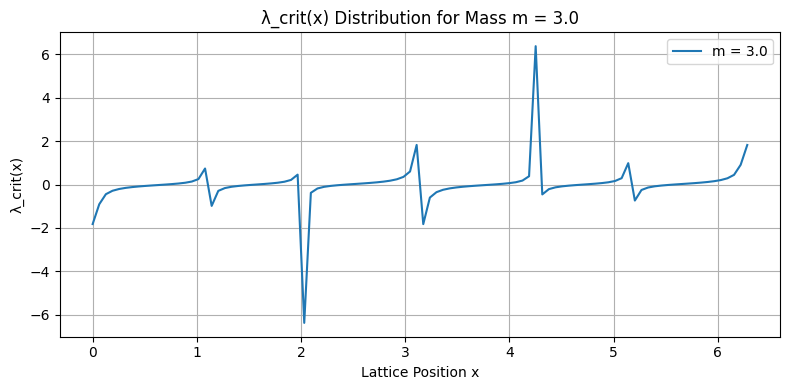

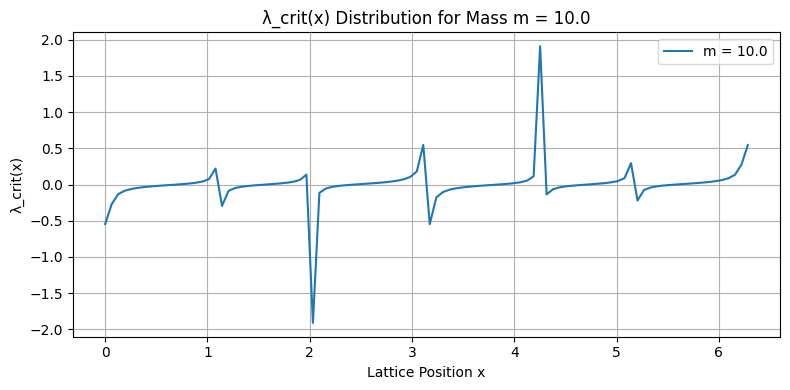

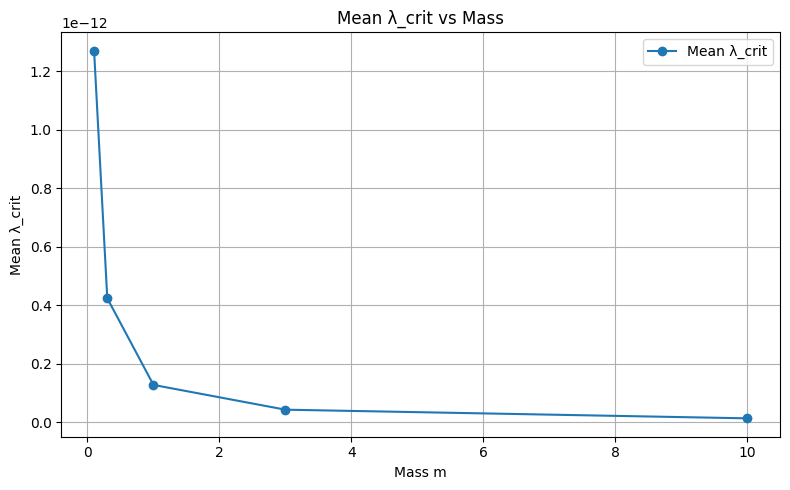

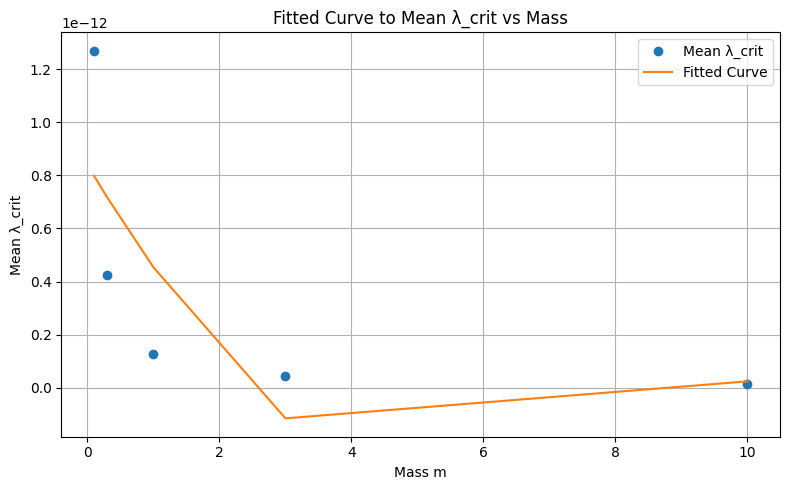

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
lattice_size = 100
mass_values = [0.1, 0.3, 1.0, 3.0, 10.0]

# Generate entropic field S(x)
x = np.linspace(0, 2 * np.pi, lattice_size)
S = np.sin(x) + 0.5 * np.sin(3 * x)  # Composite wave

# Compute gradient and curvature
grad_S = np.gradient(S, x)
curv_S = np.gradient(grad_S, x)

# Store results
mean_lambda_crit = []
lambda_crit_distributions = {}

# Compute λ_crit(x) for each mass
for m in mass_values:
    lambda_crit = grad_S / (m * curv_S)
    lambda_crit_distributions[m] = lambda_crit
    mean_lambda_crit.append(np.mean(lambda_crit))

    # Plot λ_crit(x) distribution
    plt.figure(figsize=(8, 4))
    plt.plot(x, lambda_crit, label=f"m = {m}")
    plt.title(f"λ_crit(x) Distribution for Mass m = {m}")
    plt.xlabel("Lattice Position x")
    plt.ylabel("λ_crit(x)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot mean λ_crit vs mass
plt.figure(figsize=(8, 5))
plt.plot(mass_values, mean_lambda_crit, 'o-', label="Mean λ_crit")
plt.title("Mean λ_crit vs Mass")
plt.xlabel("Mass m")
plt.ylabel("Mean λ_crit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Fit quadratic curve to mean λ_crit(m)
coeffs = np.polyfit(mass_values, mean_lambda_crit, deg=2)
fit_curve = np.polyval(coeffs, mass_values)

# Plot fitted curve
plt.figure(figsize=(8, 5))
plt.plot(mass_values, mean_lambda_crit, 'o', label="Mean λ_crit")
plt.plot(mass_values, fit_curve, '-', label="Fitted Curve")
plt.title("Fitted Curve to Mean λ_crit vs Mass")
plt.xlabel("Mass m")
plt.ylabel("Mean λ_crit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
